# Plotting

Currently, NeuRosetta offers two options to plot in 2-dimensions, a more extensive suite for 3-dimensional plotting using [vedo](https://vedo.embl.es/).


In [1]:
import matplotlib.pyplot as plt
import neurosetta as nr

%matplotlib inline

tree = nr.load_example_data(nr.example_ids[0])
tree.summary()


ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False


## 2D Plots

You have two options here, a 2-dimensional projection, or a dendrogram.

### 2-D plots

Using matplotlib, you can plot neurons in 2D using either `Tree.show_2d()` or `nr.plot_2d(tree)`. Both options do the same thing and have the same arguments. You can use it without having matplotlib directly imported:

<Axes: >

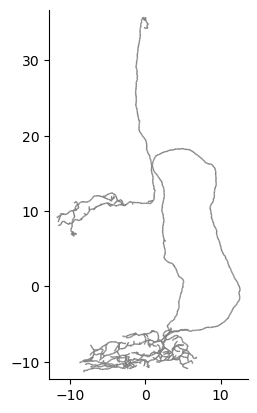

In [2]:
tree.show_2d()

However, as a `matplotlib.pyplot.Axes` object is returned, you can get additional flexibility from matplotlib. You don't technically have to, but you can use the `axes` argument to pass the plot to a created axes object: 

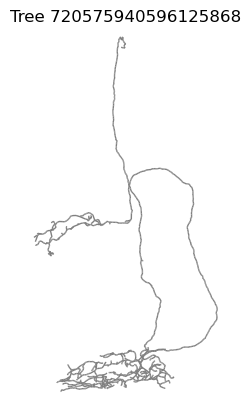

In [3]:
fig, ax = plt.subplots()
tree.show_2d(axes = ax)
ax.set_title(f"Tree {tree.ID}")
ax.set_axis_off()
plt.show()


An important argument to be aware of here is `force_perspective` which is `True` by default. This argument when `True` will rotate the neuron in a way to maximise the viewing field and align it with the global `[x,y]` axis. If False, the native coordinates are used and projected onto whatever the z-axis is:

<Axes: >

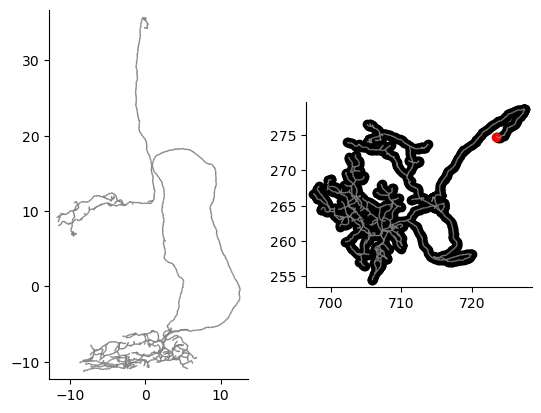

In [4]:
fig, axes = plt.subplots(1,2)

tree.show_2d(force_perspective=True, axes = axes[0])
tree.show_2d(force_perspective=False, axes = axes[1])

### Dendrograms

As above, you have both `tree.show_dendrogram()` and `nr.plot_dendrogram(tree)`.


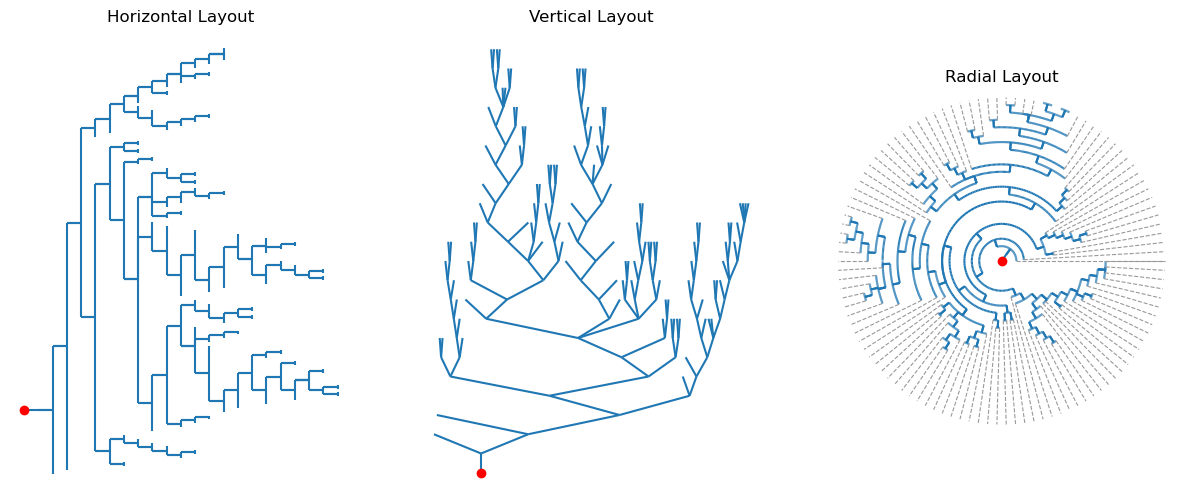

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

tree.show_dendrogram(orientation="horizontal", edge_style="orthogonal", axes=axes[0])
tree.show_dendrogram(orientation="vertical", edge_style="diagonal", axes=axes[1])
tree.show_dendrogram(
    orientation="radial", axes=axes[2], edge_style="orthogonal", align_leaves=True
)

axes[0].set_title("Horizontal Layout")
axes[1].set_title("Vertical Layout")
axes[2].set_title("Radial Layout")

plt.show()

I quite enjoy playing with layout algorithms, so I may add more in the future.

## 3-Dimensional Plotting

NeuRosetta uses [vedo](https://vedo.embl.es/site/index.html) to generate interactive 3D plots. By default, this uses `vtk` and opens an external viewing window, and is really built with that in mind.

`vedo` offers a few rendering backends and the only one I have gotten working (for the sake of this specific tutorial) is `k3d`. NeuRosetta can handle this, but with a hardcoded limit from `k3d` for 200 lines max, so it isn't hugely useful. 

All functionailty demonstrate here works the same way in the external viewer using the default `vtk` backend, so these are just examples.

`k3d` is an additional (entierly optional) dependency in the environment, and can be installed with:

```bash
mamba install k3d
```
or
```bash
pip install k3d
```
In your active NeuRosetta environment. You can change the default NeuRosetta vedo backend using:



In [6]:
nr.config.configure(vedo_backend='k3d');



For static documentation builds (`make html`), live Jupyter widgets are not embedded reliably. The example below exports a self-contained k3d HTML snapshot that still renders interactively in the built docs.

Read more about the gobal configuration setting for NeuRosetta in {doc}`../reference/configuration`.

Because of the 200 lilne limit imposed by `k3d` I am also generating some synthetic trees. These are of no scientific use to anyone, but kind of fun. The functionality for this isn't exposed to the user direectly, so you have to import the following functions:

In [7]:
from IPython.display import HTML
from neurosetta.testing import make_synthetic_forest, make_synthetic_tree

The quickest way for a rough plot is, like the 2D methods, using `tree.show_3d()`:

In [8]:
s_tree = make_synthetic_tree()
plot = s_tree.show_3d(show_root = False)

# this is so the plot renders properly in the docs, so ignore it
plot.snapshot_type = "inline"
HTML(plot.get_snapshot())

The `Tree` class has `tree.plot3d` property, through which you can access the 3D plot and set things like colour and line width, etc. Typically this is done using `tree.plot3d.style()` which exposes a range of options, minimally being:

|Argument|Aliases|Useage|
|-|-|-|
|`colour`|`color`,`c`|Neuron plot line colour|
|`llinewidth`|`lilne_width`,`lw` |Neuron lilne width|
|`alpha`| `a` |Neuron alpha value|
|`root_colour`|`root_color`,`root_c`,`rc`|Colour of point used for root|
|`root_alpha`|`root_a`,`ra`|Alpha value of root|
|`root_size`|`root_s`,`rs`|Size of root|
|`show_root`||If to show the root or not|

For example:


In [10]:
s_tree.plot3d.style(c = 'r', show_root = False)
plot = s_tree.show_3d()

# this is so the plot renders properly in the docs, so ignore it
plot.snapshot_type = "inline"
HTML(plot.get_snapshot())


In [11]:
s_forest = make_synthetic_forest()

plot = s_forest.show_3d(show_root = False)

# this is so the plot renders properly in the docs, so ignore it
plot.snapshot_type = "inline"
HTML(plot.get_snapshot())

For the greatest flexbility you can use NeuRosettas in built viewer, which as well as being usefull to plot neurons and forests, can also handle meshes or any other `vedo` plotting object.

Next: {doc}`tree_surgery`.
